<a href="https://colab.research.google.com/github/omarbemo/Data_Analysis/blob/main/CustomerPersonality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "marketing_campaign.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "imakash3011/customer-personality-analysis",
  file_path,
  pandas_kwargs={'sep': '\t'}
)

/tmp/ipython-input-2325598151.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'customer-personality-analysis' dataset.


In [ ]:
df


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
df['Education'].value_counts()

,count
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54


In [ ]:
df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


Replace the null values in the income

In [ ]:
df['Income'].isnull().sum()

np.int64(24)

In [ ]:
df.fillna(df['Income'].median(), inplace=True)

### Removing Outliers from 'Income' using the IQR Method

First, let's look at the current descriptive statistics for the 'Income' column to understand its distribution before outlier removal.

Descriptive statistics for 'Income' BEFORE outlier removal:


,Income
count,2240.000000
mean,52237.975446
std,25037.955891
min,1730.000000
25%,35538.750000
50%,51381.500000
75%,68289.750000
max,666666.000000



Q1: 35538.75, Q3: 68289.75, IQR: 32751.0

Lower bound for outliers: -13587.75
Upper bound for outliers: 117416.25

Original DataFrame shape: (2240, 29)
DataFrame shape AFTER outlier removal: (2232, 29)
Number of outliers removed: 8

Descriptive statistics for 'Income' AFTER outlier removal:


,Income
count,2232.000000
mean,51630.926971
std,20601.679542
min,1730.000000
25%,35434.750000
50%,51381.500000
75%,68118.000000
max,113734.000000


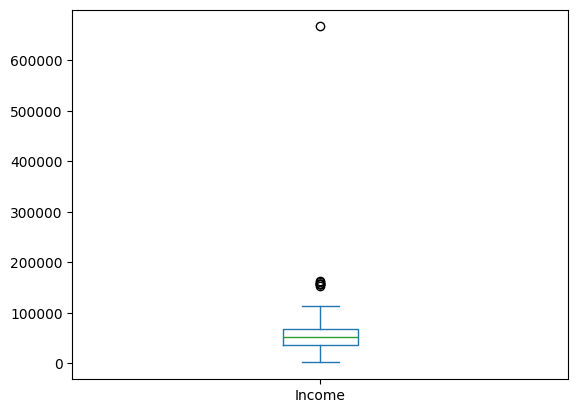

In [ ]:
print("Descriptive statistics for 'Income' BEFORE outlier removal:")
display(df['Income'].describe())

# Calculate Q1, Q3, and IQR
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1
print(f"\nQ1: {Q1}, Q3: {Q3}, IQR: {IQR}")
df.Income.plot.box()
# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Display the calculated bounds
print(f"\nLower bound for outliers: {lower_bound}")
print(f"Upper bound for outliers: {upper_bound}")

# Filter out the outliers
original_shape = df.shape
df_no_outliers = df[(df['Income'] >= lower_bound) & (df['Income'] <= upper_bound)]

# Display the shape before and after removal
print(f"\nOriginal DataFrame shape: {original_shape}")
print(f"DataFrame shape AFTER outlier removal: {df_no_outliers.shape}")
print(f"Number of outliers removed: {original_shape[0] - df_no_outliers.shape[0]}")

# Display descriptive statistics for 'Income' AFTER outlier removal
print("\nDescriptive statistics for 'Income' AFTER outlier removal:")
display(df_no_outliers['Income'].describe())

# Assign the filtered DataFrame back to df if you wish to apply this change permanently
df = df_no_outliers.copy()

In [ ]:
df.Income.describe()

,Income
count,2232.000000
mean,51630.926971
std,20601.679542
min,1730.000000
25%,35434.750000
50%,51381.500000
75%,68118.000000
max,113734.000000


Drop no needed columns

In [ ]:
df.drop('ID' , axis=1, inplace=True)

In [ ]:
df.drop('Z_CostContact' , axis=1, inplace=True)
df.drop('Z_Revenue' , axis=1, inplace=True)

In [ ]:
import pandas as pd

# Display descriptive statistics for 'Year_Birth' to help determine thresholds
display(df['Year_Birth'].describe())
print(f"Current DataFrame shape: {df.shape}")

Q1 = df['Year_Birth'].quantile(0.25)
Q3 = df['Year_Birth'].quantile(0.75)
IQR = Q3 - Q1
print(f"\nQ1: {Q1}, Q3: {Q3}, IQR: {IQR}")
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"\nLower bound for outliers: {lower_bound}")
print(f"Upper bound for outliers: {upper_bound}")
df = df[(df['Year_Birth'] >= lower_bound) & (df['Year_Birth'] <= upper_bound)]
print(f"\nDataFrame shape AFTER outlier removal: {df.shape}")
display(df['Year_Birth'].describe())

,Year_Birth
count,2232.000000
mean,1968.792563
std,11.990340
min,1893.000000
25%,1959.000000
50%,1970.000000
75%,1977.000000
max,1996.000000


Current DataFrame shape: (2232, 26)

Q1: 1959.0, Q3: 1977.0, IQR: 18.0

Lower bound for outliers: 1932.0
Upper bound for outliers: 2004.0

DataFrame shape AFTER outlier removal: (2229, 26)


,Year_Birth
count,2229.000000
mean,1968.888739
std,11.707430
min,1940.000000
25%,1959.000000
50%,1970.000000
75%,1977.000000
max,1996.000000


In [ ]:
df.loc[:,'Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

**Age** **column** Based on the current year (2025)

In [ ]:
df.loc[:,'Age']=2025-df['Year_Birth']

In [ ]:
display(df.head())


,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,4,7,0,0,0,0,0,0,1,68
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,2,5,0,0,0,0,0,0,0,71
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,10,4,0,0,0,0,0,0,0,60
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,4,6,0,0,0,0,0,0,0,41
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,6,5,0,0,0,0,0,0,0,44


**Num of total children at a house**

In [ ]:
df.loc[:,'NumOfChildren']=df['Kidhome']+df['Teenhome']

**Total Spendings**

In [ ]:
df.loc[:,'TotalSpendings']  = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

Column identifies if a person accepted any campaign

In [ ]:
df.loc[:,'AcceptedAtAll'] = (df['AcceptedCmp1'] + df['AcceptedCmp2'] + df['AcceptedCmp3'] + df['AcceptedCmp4'] + df['AcceptedCmp5'] + df['Response'] >= 1).astype(int)
display(df.head())

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Response,Age,NumOfChildren,TotalSpendings,AcceptedAtAll,TotalPurchases,Recency_Group,Age_Group,CustomerTenure,CustomerTenure_Group
0,1957,Graduation,Single/Other,58138.0,0,0,2012-09-04,58,635,88,...,1,68,0,1617,1,25,31-60 days,61-70,1.815195,1-2 years
1,1954,Graduation,Single/Other,46344.0,1,1,2014-03-08,38,11,1,...,0,71,2,27,0,6,31-60 days,71-80,0.309377,0-1 year
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,0,60,0,776,0,21,0-30 days,51-60,0.854209,0-1 year
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,0,41,1,53,0,8,0-30 days,41-50,0.380561,0-1 year
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,0,44,1,422,0,19,61-99 days,41-50,0.440794,0-1 year


Reduce number of unneeded categories in Marital_Status

In [ ]:
import numpy as np
df.loc[:,'Marital_Status'] = np.where(
    (df['Marital_Status'] != 'Married') &(df['Marital_Status'] != 'Together'),
    'Single/Other',
    df['Marital_Status']
)
display(df['Marital_Status'].value_counts())

,count
Marital_Status,
Married,861
Single/Other,793
Together,575


column for Total number of purchases

In [ ]:
df.loc[:,'TotalPurchases'] = df['NumDealsPurchases'] + df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']

I have done the preproccesing for the data lets analyze

Q1) Number of people in each education category

In [ ]:
df.Education.value_counts()

,count
Education,
Graduation,1124
PhD,481
Master,369
2n Cycle,201
Basic,54


Q2) number of people in each martial status

In [ ]:
df.Marital_Status.value_counts()

,count
Marital_Status,
Married,861
Single/Other,793
Together,575


Q3) Statistics for Income

In [ ]:
df.Income.describe()

,Income
count,2229.000000
mean,51619.504262
std,20601.216248
min,1730.000000
25%,35416.000000
50%,51381.500000
75%,68118.000000
max,113734.000000


Q4) Statistics for Birth dates

In [ ]:
df.Year_Birth.describe()


,Year_Birth
count,2229.000000
mean,1968.888739
std,11.707430
min,1940.000000
25%,1959.000000
50%,1970.000000
75%,1977.000000
max,1996.000000


Q5) Statistics for kids at home

In [ ]:
df.Kidhome.describe()

,Kidhome
count,2229.000000
mean,0.444594
std,0.538636
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,2.000000


In [ ]:
df.Kidhome.value_counts()

,count
Kidhome,
0,1286
1,895
2,48


Q6) Statistics for teenagers

In [ ]:
df.Teenhome.describe()


,Teenhome
count,2229.000000
mean,0.507402
std,0.544735
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,2.000000


In [ ]:
df.Teenhome.value_counts()

,count
Teenhome,
0,1150
1,1027
2,52


Q7) Decribe the Recency column

In [ ]:
df.Recency.describe()

,Recency
count,2229.000000
mean,49.106326
std,28.946476
min,0.000000
25%,24.000000
50%,49.000000
75%,74.000000
max,99.000000


Q8) How many complaints

In [ ]:
print(f"Number of complaints: {df.Complain.value_counts()[1]}")

Number of complaints: 20


Q9) decribe all the products Statistics

In [ ]:
df.MntWines.describe()

,MntWines
count,2229.000000
mean,304.991476
std,336.761943
min,0.000000
25%,24.000000
50%,176.000000
75%,505.000000
max,1493.000000


In [ ]:
print(f"The total spendings on wines is: {df.MntWines.sum()}")

The total spendings on wines is: 679826


In [ ]:
df.MntFruits.describe()

,MntFruits
count,2229.000000
mean,26.348587
std,39.764060
min,0.000000
25%,2.000000
50%,8.000000
75%,33.000000
max,199.000000


In [ ]:
print(f"The total spendings on fruits is: {df.MntFruits.sum()}")

The total spendings on fruits is: 58731


In [ ]:
df.MntMeatProducts.describe()

,MntMeatProducts
count,2229.000000
mean,165.283984
std,219.336589
min,0.000000
25%,16.000000
50%,67.000000
75%,231.000000
max,1725.000000


In [ ]:
print(f"The total spendings on Meat products is: {df.MntMeatProducts.sum()}")

The total spendings on Meat products is: 368418


In [ ]:
df.MntFishProducts.describe()

,MntFishProducts
count,2229.000000
mean,37.642441
std,54.700548
min,0.000000
25%,3.000000
50%,12.000000
75%,50.000000
max,259.000000


In [ ]:
print(f"The total spendings on fish products is: {df.MntFishProducts.sum()}")

The total spendings on fish products is: 83905


In [ ]:
df.MntSweetProducts.describe()

,MntSweetProducts
count,2229.000000
mean,27.161507
std,41.338945
min,0.000000
25%,1.000000
50%,8.000000
75%,34.000000
max,263.000000


In [ ]:
print(f"The total spendings on sweet products is: {df.MntSweetProducts.sum()}")

The total spendings on sweet products is: 60543


In [ ]:
df.MntGoldProds.describe()

,MntGoldProds
count,2229.000000
mean,44.113055
std,52.091255
min,0.000000
25%,9.000000
50%,24.000000
75%,56.000000
max,362.000000


In [ ]:
print(f"The total spendings on Gold products is: {df.MntGoldProds.sum()}")

The total spendings on Gold products is: 98328


Q10) Describe each campaign Statistics

In [ ]:
print(f"Number of Acceptance for the first campaign: {df['AcceptedCmp1'].value_counts()[1]}")

Number of Acceptance for the first campaign: 144


In [ ]:
print(f"Number of Acceptance for the second campaign: {df['AcceptedCmp2'].value_counts()[1]}")

Number of Acceptance for the second campaign: 30


In [ ]:
print(f"Number of Acceptance for the third campaign: {df['AcceptedCmp3'].value_counts()[1]}")

Number of Acceptance for the third campaign: 163


In [ ]:
print(f"Number of Acceptance for the fourth campaign: {df['AcceptedCmp4'].value_counts()[1]}")

Number of Acceptance for the fourth campaign: 167


In [ ]:
print(f"Number of Acceptance for the fifth campaign: {df['AcceptedCmp5'].value_counts()[1]}")

Number of Acceptance for the fifth campaign: 162


In [ ]:
print(f"Number of Acceptance for the last campaign: {df['Response'].value_counts()[1]}")

Number of Acceptance for the last campaign: 334


Q11) Statistices for The web store

In [ ]:
print(f"Sum of total web visits last month: {df['NumWebVisitsMonth'].sum()}")

Sum of total web visits last month: 11890


In [ ]:
print(f"Sum of total web purchases: {df['NumWebPurchases'].sum()}")

Sum of total web purchases: 9139


In [ ]:
df['NumWebPurchases'].describe()

,NumWebPurchases
count,2229.000000
mean,4.100045
std,2.775461
min,0.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,27.000000


Q12) Statistices for the Catalog purchases

In [ ]:
print(f"Sum of total Catalog purchases: {df['NumCatalogPurchases'].sum()}")

Sum of total Catalog purchases: 5877


In [ ]:
df['NumCatalogPurchases'].describe()

,NumCatalogPurchases
count,2229.000000
mean,2.636608
std,2.796161
min,0.000000
25%,0.000000
50%,2.000000
75%,4.000000
max,28.000000


Q13) Statistices for store purchases

In [ ]:
print(f"Sum of total stores purchases: {df['NumStorePurchases'].sum()}")

Sum of total stores purchases: 12956


In [ ]:
df['NumStorePurchases'].describe()

,NumStorePurchases
count,2229.000000
mean,5.812472
std,3.242144
min,0.000000
25%,3.000000
50%,5.000000
75%,8.000000
max,13.000000


This is the analysis for the basic columns

Now lets analyze the extra columns

In [ ]:
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,NumOfChildren,TotalSpendings,AcceptedAtAll,TotalPurchases
0,1957,Graduation,Single/Other,58138.0,0,0,2012-09-04,58,635,88,...,0,0,0,0,1,68,0,1617,1,25
1,1954,Graduation,Single/Other,46344.0,1,1,2014-03-08,38,11,1,...,0,0,0,0,0,71,2,27,0,6
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,0,0,0,0,0,60,0,776,0,21
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,0,0,0,0,0,41,1,53,0,8
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,0,0,0,0,0,44,1,422,0,19


In [ ]:
df.Age.describe()

,Age
count,2229.000000
mean,56.111261
std,11.707430
min,29.000000
25%,48.000000
50%,55.000000
75%,66.000000
max,85.000000


In [ ]:
df.NumOfChildren.describe()

,NumOfChildren
count,2229.000000
mean,0.951996
std,0.751976
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,3.000000


In [ ]:
df.NumOfChildren.value_counts()

,count
NumOfChildren,
1,1123
0,633
2,420
3,53


In [ ]:
df.TotalSpendings.describe()

,TotalSpendings
count,2229.000000
mean,605.541050
std,601.032228
min,5.000000
25%,69.000000
50%,397.000000
75%,1044.000000
max,2525.000000


In [ ]:
print(f"Total sales for all products: {df.TotalSpendings.sum()}")

Total sales for all products: 1349751


In [ ]:
print(f"How many people accepted at least one campaign: {df.AcceptedAtAll.value_counts()[1]}")

How many people accepted at least one campaign: 608


In [ ]:
df.TotalPurchases.describe()

,TotalPurchases
count,2229.000000
mean,14.869000
std,7.622187
min,0.000000
25%,8.000000
50%,15.000000
75%,21.000000
max,43.000000


In [ ]:
print(f"{df.TotalPurchases.sum()} purchases were made")

33143 purchases were made


Now we have analyzed each column sperately

Lets analyze more than one column at once

Q1)Analyze how Income, Total Spendings, and Total Purchases differ across various Education levels and Marital Statuses.

In [ ]:
df.groupby(['Education','Marital_Status']).agg({'Income':'mean',
    'TotalSpendings': 'mean',
    'TotalPurchases': 'mean'})

Income  TotalSpendings  TotalPurchases
Education  Marital_Status                                              
2n Cycle   Married         46265.055556      423.790123       13.197531
           Single/Other    52061.436508      606.714286       14.460317
           Together        44852.991228      494.000000       14.245614
Basic      Married         21960.500000      122.850000        7.900000
           Single/Other    17998.350000       58.500000        7.200000
           Together        21240.071429       56.428571        5.500000
Graduation Married         50805.628176      595.912240       14.946882
           Single/Other    52348.461916      619.464373       14.874693
           Together        53234.987676      657.309859       15.242958
Master     Married         53286.028986      566.666667       14.927536
           Single/Other    53156.273810      704.039683       15.015873
           Together        51075.352381      565.628571       14.942857
PhD        Married         56476.291005      709.555556       16.306878
           Single/Other    54020.497175      640.412429       15.615819
           Together        54837.021739      643.817391       15.217391

In [ ]:
df.groupby(['Education','Marital_Status']).size()

Education   Marital_Status
2n Cycle    Married            81
            Single/Other       63
            Together           57
Basic       Married            20
            Single/Other       20
            Together           14
Graduation  Married           433
            Single/Other      407
            Together          284
Master      Married           138
            Single/Other      126
            Together          105
PhD         Married           189
            Single/Other      177
            Together          115
dtype: int64

Q2) Analyze how Income, Total Spendings, and Total Purchases vary across different Education levels, Marital Statuses, and the Number of Children.



In [ ]:
grouped_data = df.groupby(['Education', 'Marital_Status', 'NumOfChildren']).agg({
    'Income': 'mean',
    'TotalSpendings': 'mean',
    'TotalPurchases': 'mean'
})

display(grouped_data)

Income  TotalSpendings  \
Education  Marital_Status NumOfChildren                                 
2n Cycle   Married        0              57782.269231      775.384615   
                          1              39474.695122      287.975610   
                          2              46274.333333      161.500000   
                          3              35688.000000      211.000000   
           Single/Other   0              64845.100000     1054.400000   
                          1              47074.156250      477.843750   
                          2              42440.050000      182.700000   
                          3              52195.000000       17.000000   
           Together       0              49788.694444      775.222222   
                          1              42803.730769      423.923077   
                          2              42117.461538      244.769231   
Basic      Married        0              22699.222222      205.333333   
                          1              21356.090909       55.363636   
           Single/Other   0              17870.000000       64.000000   
                          1              18352.466667       56.800000   
                          2              15535.000000       63.000000   
           Together       0              21826.200000       55.000000   
                          1              20914.444444       57.222222   
Graduation Married        0              62634.935345     1028.637931   
                          1              47352.097345      514.654867   
                          2              44387.601190      240.214286   
                          3              43293.142857      316.857143   
           Single/Other   0              64511.139535     1061.395349   
                          1              47076.524390      464.351220   
                          2              45209.304688      263.218750   
                          3              48867.111111      351.555556   
           Together       0              73017.027027     1324.486486   
                          1              48032.095238      501.197279   
                          2              41823.768519      237.351852   
                          3              44030.555556      241.222222   
Master     Married        0              70618.366667     1178.166667   
                          1              49230.944444      444.555556   
                          2              46751.727273      302.242424   
                          3              49162.000000      291.000000   
           Single/Other   0              65500.255556     1308.577778   
                          1              47462.960784      447.803922   
                          2              44971.000000      261.500000   
                          3              40080.500000       46.500000   
           Together       0              64162.462963     1120.703704   
                          1              46895.685185      403.777778   
                          2              45951.456522      315.956522   
                          3              41275.000000       61.000000   
PhD        Married        0              72192.829787     1337.659574   
                          1              53080.903061      601.846939   
                          2              46284.794872      267.128205   
                          3              54784.100000      367.400000   
           Single/Other   0              68634.919643     1137.142857   
                          1              49344.046667      541.800000   
                          2              43148.615385      198.051282   
                          3              47781.857143      187.714286   
           Together       0              73136.178571     1340.071429   
                          1              49720.713115      489.918033   
                          2              45603.095238      206.714286   
                          3     

In [ ]:
df.groupby(['Education', 'Marital_Status', 'NumOfChildren']).size()

Education   Marital_Status  NumOfChildren
2n Cycle    Married         0                 26
                            1                 41
                            2                 12
                            3                  2
            Single/Other    0                 20
                            1                 32
                            2                 10
                            3                  1
            Together        0                 18
                            1                 26
                            2                 13
Basic       Married         0                  9
                            1                 11
            Single/Other    0                  3
                            1                 15
                            2                  2
            Together        0                  5
                            1                  9
Graduation  Married         0                116
                            1                226
                            2                 84
                            3                  7
            Single/Other    0                129
                            1                205
                            2                 64
                            3                  9
            Together        0                 74
                            1                147
                            2                 54
                            3                  9
Master      Married         0                 30
                            1                 72
                            2                 33
                            3                  3
            Single/Other    0                 45
                            1                 51
                            2                 26
                            3                  4
            Together        0                 27
                            1                 54
                            2                 23
                            3                  1
PhD         Married         0                 47
                            1                 98
                            2                 39
                            3                  5
            Single/Other    0                 56
                            1                 75
                            2                 39
                            3                  7
            Together        0                 28
                            1                 61
                            2                 21
                            3                  5
dtype: int64

Q3)How does the 'NumOfChildren' impact the 'TotalSpendings' and 'Total purchases' for each 'Education' level?

In [ ]:
df.groupby(['Education','NumOfChildren']).agg({
    'TotalSpendings': 'mean',
    'TotalPurchases': 'mean'
})

TotalSpendings  TotalPurchases
Education  NumOfChildren                                
2n Cycle   0                  862.531250       16.875000
           1                  385.050505       13.353535
           2                  198.485714       10.114286
           3                  146.333333       12.000000
Basic      0                  136.176471        7.588235
           1                   56.457143        6.514286
           2                   63.000000       11.000000
Graduation 0                 1110.514107       17.567398
           1                  493.391003       14.707612
           2                  246.737624       12.351485
           3                  302.120000       10.200000
Master     0                 1220.490196       17.745098
           1                  433.050847       14.028249
           2                  293.170732       13.939024
           3                  140.000000       10.625000
PhD        0                 1252.458015       19.015267
           1                  553.423077       15.982906
           2                  227.101010       11.333333
           3                  320.117647       14.294118

Q4)How does the 'NumOfChildren' impact the 'TotalSpendings' and 'Total purchases' for each 'Marital status'?

In [ ]:
df.groupby(['Marital_Status','NumOfChildren']).agg({
    'TotalSpendings': 'mean',
    'TotalPurchases': 'mean'
})

TotalSpendings  TotalPurchases
Marital_Status NumOfChildren                                
Married        0                 1050.635965       17.140351
               1                  490.439732       14.700893
               2                  253.023810       12.619048
               3                  314.705882       13.352941
Single/Other   0                 1109.747036       17.687747
               1                  462.455026       14.399471
               2                  236.326241       11.531915
               3                  222.904762       10.523810
Together       0                 1184.355263       17.967105
               1                  460.949495       14.292929
               2                  248.711712       12.522523
               3                  301.533333       11.400000

Q5) Analyze of income impact on "Total spendings" and ' Total Purchases'

In [ ]:
income_spending_corr = df['Income'].corr(df['TotalSpendings'])
income_purchases_corr = df['Income'].corr(df['TotalPurchases'])

print(f"Correlation between Income and Total Spendings: {income_spending_corr:.2f}")
print(f"Correlation between Income and Total Purchases: {income_purchases_corr:.2f}")
print("This suggests that as income increases, total spending tends to increase significantly.")
print("This also indicates that higher income is associated with a greater number of purchases.")

Correlation between Income and Total Spendings: 0.82
Correlation between Income and Total Purchases: 0.70
This suggests that as income increases, total spending tends to increase significantly.
This also indicates that higher income is associated with a greater number of purchases.


Q6) Analyzing Average Income, Total Spendings, and Total Purchases by Campaign Acceptance Status

In [ ]:
campaign_acceptance_summary = df.groupby('AcceptedAtAll').agg({
    'Income': 'mean',
    'TotalSpendings': 'mean',
    'TotalPurchases': 'mean'
})

display(campaign_acceptance_summary)

,Income,TotalSpendings,TotalPurchases
AcceptedAtAll,,,
0,47857.105490,457.613819,13.685379
1,61650.504934,999.932566,18.024671


Q7) Analyzing Average Income, Total Spendings, and Total Purchases by complain

In [ ]:
campaign_acceptance_summary = df.groupby('Complain').agg({
    'Income': 'mean',
    'TotalSpendings': 'mean',
    'TotalPurchases': 'mean'
})
display(campaign_acceptance_summary)

,Income,TotalSpendings,TotalPurchases
Complain,,,
0,51673.348574,607.474423,14.880489
1,45672.400000,392.000000,13.600000


Q8)Analyzing average of "NumDealsPurchases" by Marital status and education level

In [ ]:
df.groupby(['Education','Marital_Status']).agg({
    'NumDealsPurchases': 'mean'
})

NumDealsPurchases
Education  Marital_Status                   
2n Cycle   Married                  2.123457
           Single/Other             2.047619
           Together                 2.684211
Basic      Married                  1.800000
           Single/Other             2.150000
           Together                 1.285714
Graduation Married                  2.346420
           Single/Other             2.275184
           Together                 2.313380
Master     Married                  2.536232
           Single/Other             2.142857
           Together                 2.647619
PhD        Married                  2.449735
           Single/Other             2.389831
           Together                 2.060870

Q9) Analyze the impact of Number of children on the Total spendings and total purchases

In [ ]:
Children_spending_corr = df['NumOfChildren'].corr(df['TotalSpendings'])
children_purchases_corr = df['NumOfChildren'].corr(df['TotalPurchases'])

print(f"Correlation between NumOfChildren and Total Spendings: {Children_spending_corr:.2f}")
print(f"Correlation between NumOfChildren and Total Purchases: {children_purchases_corr:.2f}")

Correlation between NumOfChildren and Total Spendings: -0.50
Correlation between NumOfChildren and Total Purchases: -0.25


  Q)10 How does the acceptance for a champagin on Total Spendings and Total Purchases

In [ ]:
df.groupby('AcceptedAtAll').agg({
    'TotalSpendings': 'mean',
    'TotalPurchases': 'mean'
})

,TotalSpendings,TotalPurchases
AcceptedAtAll,,
0,457.613819,13.685379
1,999.932566,18.024671


Q11) Analyze Recency's Impact

In [ ]:
recency_total_spendings_corr = df['Recency'].corr(df['TotalSpendings'])
recency_total_purchases_corr = df['Recency'].corr(df['TotalPurchases'])
recency_accepted_corr=df['Recency'].corr(df['AcceptedAtAll'])
recency_complain_corr=df['Recency'].corr(df['Complain'])
print(f"Correlation between Recency and Total Spendings: {recency_total_spendings_corr:.2f}")
print(f"Correlation between Recency and Total Purchases: {recency_total_purchases_corr:.2f}")
print(f"Correlation between Recency and AcceptedAtAll: {recency_accepted_corr:.2f}")
print(f"Correlation between Recency and Complain: {recency_complain_corr:.2f}")



recnecy_bins=[0,30,60,99]
recency_labels=['0-30 days','31-60 days','61-99 days']
df.loc[:,'Recency_Group']=pd.cut(df['Recency'],bins=recnecy_bins,labels=recency_labels)


df.groupby('Recency_Group').agg({
    'TotalSpendings': 'mean',
    'TotalPurchases': 'mean'
})



Correlation between Recency and Total Spendings: 0.02
Correlation between Recency and Total Purchases: 0.01
Correlation between Recency and AcceptedAtAll: -0.10
Correlation between Recency and Complain: 0.01


/tmp/ipython-input-582099723.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Recency_Group').agg({


,TotalSpendings,TotalPurchases
Recency_Group,,
0-30 days,599.310694,14.816474
31-60 days,595.425499,14.889401
61-99 days,623.315851,14.889277


Q12) Analyze Age's Impact

In [ ]:
age_accepted_corr=df['Age'].corr(df['AcceptedAtAll'])
age_complain_corr=df['Age'].corr(df['Complain'])
age_total_spendings_corr = df['Age'].corr(df['TotalSpendings'])
age_total_purchases_corr = df['Age'].corr(df['TotalPurchases'])
print(f"Correlation between Age and Total Spendings: {age_total_spendings_corr:.2f}")
print(f"Correlation between Age and Total Purchases: {age_total_purchases_corr:.2}")
print(f"Correlation between Age and AcceptedAtAll: {age_accepted_corr:.2f}")
print(f"Correlation between Age and Complain: {age_complain_corr:.2f}")


age_bins = [20,30,40,50,60,70,80,90]
age_labels = ['20-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90']
df.loc[:,'Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)


df.groupby('Age_Group').agg({
    'TotalSpendings': 'mean',
    'TotalPurchases': 'mean'})

Correlation between Age and Total Spendings: 0.12
Correlation between Age and Total Purchases: 0.18
Correlation between Age and AcceptedAtAll: 0.03
Correlation between Age and Complain: 0.00


/tmp/ipython-input-2599080176.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group').agg({


,TotalSpendings,TotalPurchases
Age_Group,,
20-30,563.428571,13.285714
31-40,610.644860,13.032710
41-50,517.742754,13.539855
51-60,553.547478,14.571217
61-70,684.079229,16.404711
71-80,732.468227,16.655518
81-90,1110.687500,20.312500


In [ ]:
current_date = df['Dt_Customer'].max() # Use the most recent customer date as a reference
df.loc[:, 'CustomerTenure'] = (current_date - df['Dt_Customer']).dt.days / 365.25

tenure_spendings_corr = df['CustomerTenure'].corr(df['TotalSpendings'])
tenure_purchases_corr = df['CustomerTenure'].corr(df['TotalPurchases'])
tenure_accepted_corr = df['CustomerTenure'].corr(df['AcceptedAtAll'])

print(f"Correlation between CustomerTenure and Total Spendings: {tenure_spendings_corr:.2f}")
print(f"Correlation between CustomerTenure and Total Purchases: {tenure_purchases_corr:.2f}")
print(f"Correlation between CustomerTenure and AcceptedAtAll: {tenure_accepted_corr:.2f}")
tenure_bins = [0, 1,2]
tenure_labels = ['0-1 year', '1-2 years' ]
df.loc[:,'CustomerTenure_Group'] = pd.cut(df['CustomerTenure'], bins=tenure_bins, labels=tenure_labels)
df.groupby('CustomerTenure_Group').agg({
    'TotalSpendings': 'mean',
    'TotalPurchases': 'mean'})


Correlation between CustomerTenure and Total Spendings: 0.16
Correlation between CustomerTenure and Total Purchases: 0.21
Correlation between CustomerTenure and AcceptedAtAll: 0.09


/tmp/ipython-input-1092306364.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('CustomerTenure_Group').agg({


,TotalSpendings,TotalPurchases
CustomerTenure_Group,,
0-1 year,522.438749,13.495222
1-2 years,695.022305,16.342007


Now lets visualize

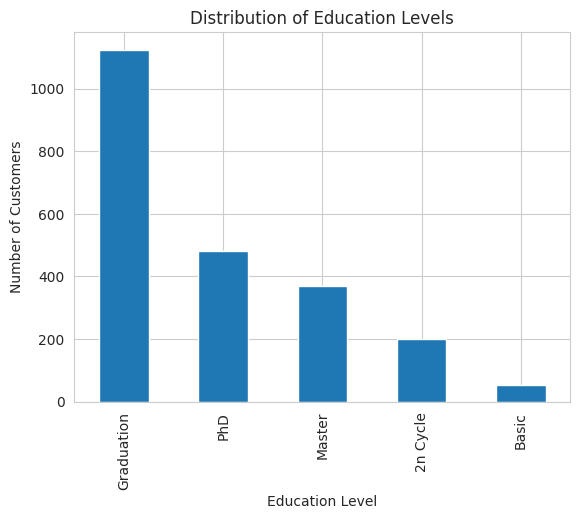

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
df.Education.value_counts().plot.bar()
plt.title('Distribution of Education Levels')
plt.xlabel('Education Level')
plt.ylabel('Number of Customers')
plt.show()

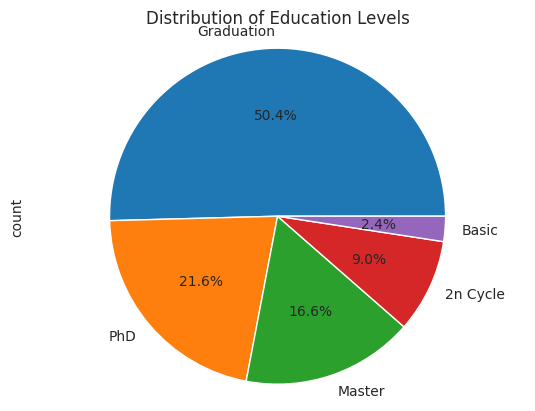

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
df.Education.value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Distribution of Education Levels')
plt.axis('equal')
plt.show()

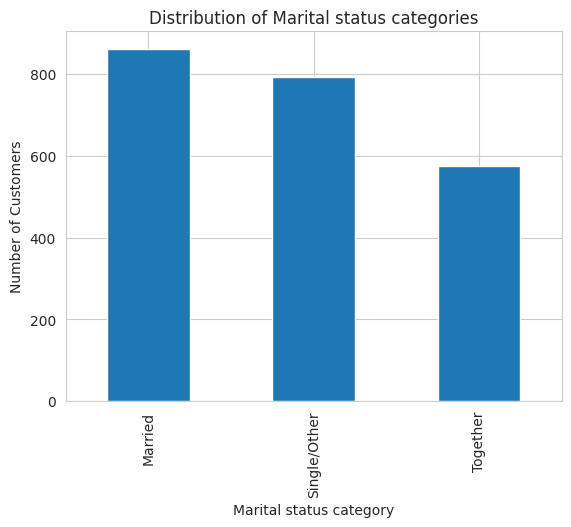

In [ ]:
sns.set_style('whitegrid')
df.Marital_Status.value_counts().plot.bar()
plt.title('Distribution of Marital status categories')
plt.xlabel('Marital status category')
plt.ylabel('Number of Customers')
plt.show()

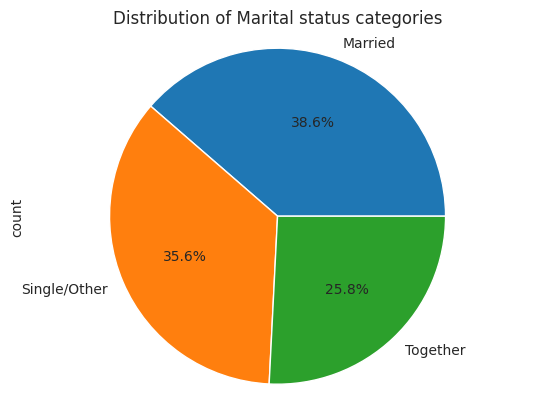

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
df.Marital_Status.value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Distribution of Marital status categories')
plt.axis('equal')
plt.show()

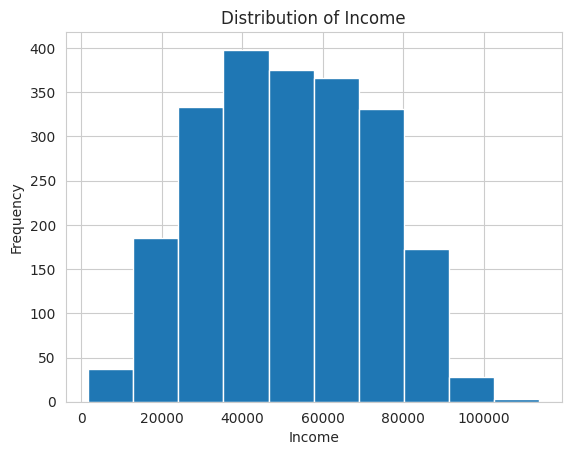

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
df.Income.plot.hist()
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

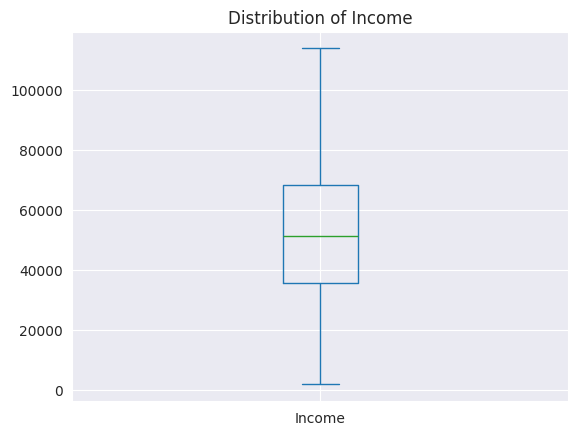

In [ ]:
sns.set_style('darkgrid')
df.Income.plot.box()
plt.title('Distribution of Income')
plt.show()

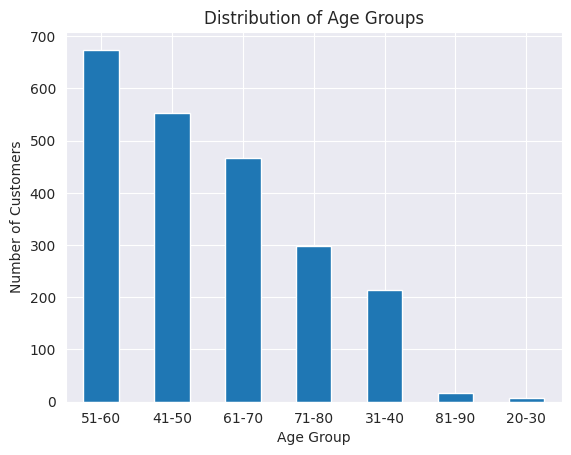

In [ ]:
sns.set_style('darkgrid')
df.Age_Group.value_counts().plot.bar()
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

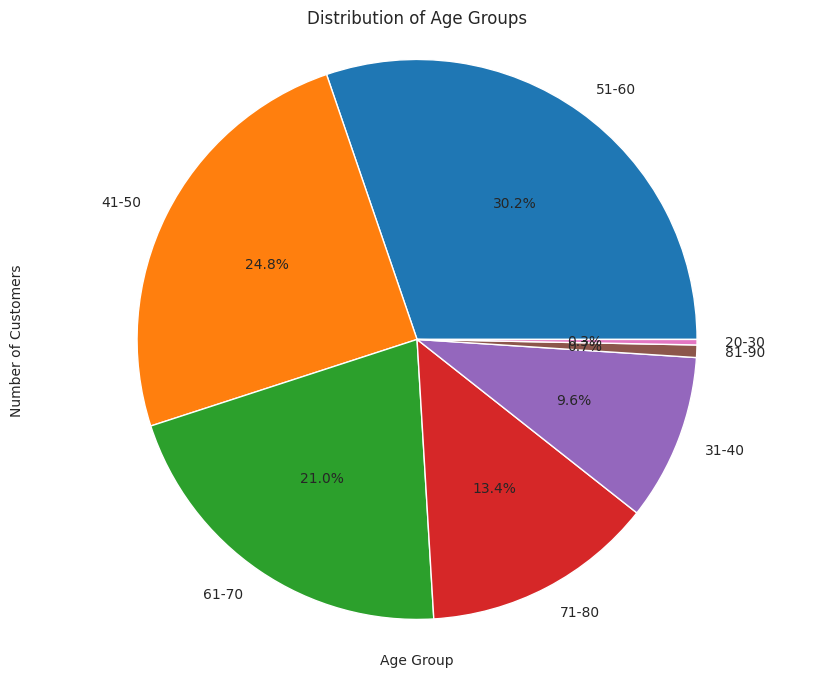

In [ ]:
plt.figure(figsize=(10, 8))
sns.set_style('darkgrid')
df.Age_Group.value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.axis('equal')
plt.show()

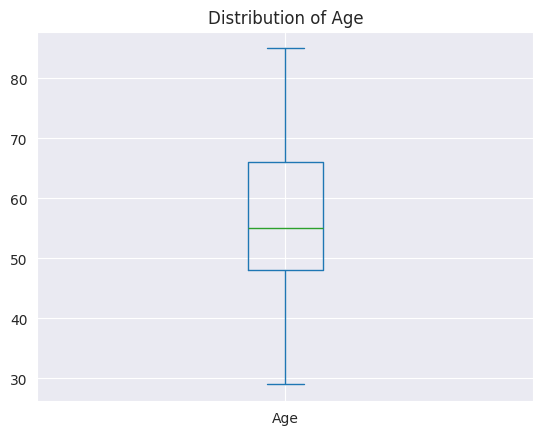

In [ ]:
sns.set_style('darkgrid')
df.Age.plot.box()
plt.title('Distribution of Age')
plt.show()


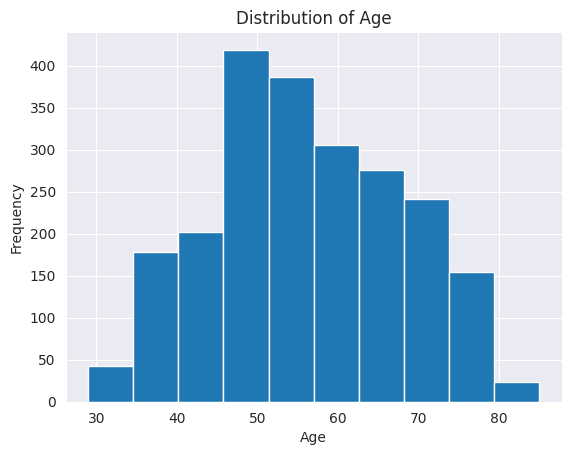

In [ ]:
sns.set_style('darkgrid')
df.Age.plot.hist()
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

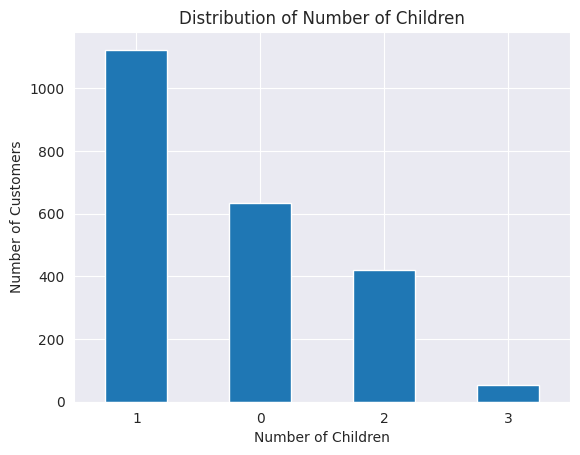

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
df.NumOfChildren.value_counts().plot.bar()
plt.title('Distribution of Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

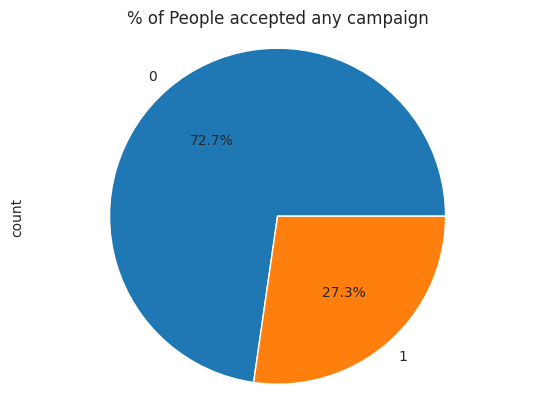

In [ ]:
sns.set_style('darkgrid')
df.AcceptedAtAll.value_counts().plot.pie(autopct='%1.1f%%')
plt.axis('equal')
plt.title('% of People accepted any campaign')
plt.show()



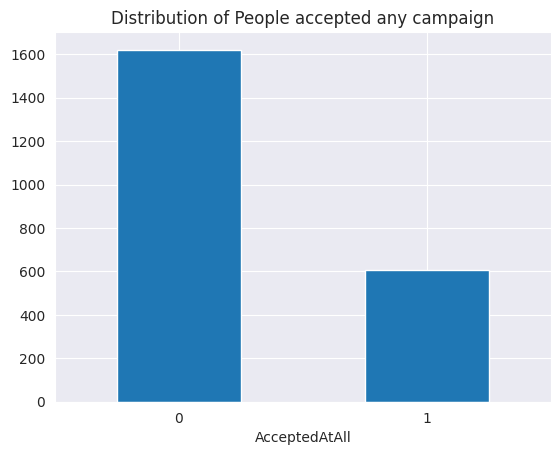

In [ ]:
sns.set_style('darkgrid')
df.AcceptedAtAll.value_counts().plot.bar()
plt.title('Distribution of People accepted any campaign')
plt.xticks(rotation=0)
plt.show()

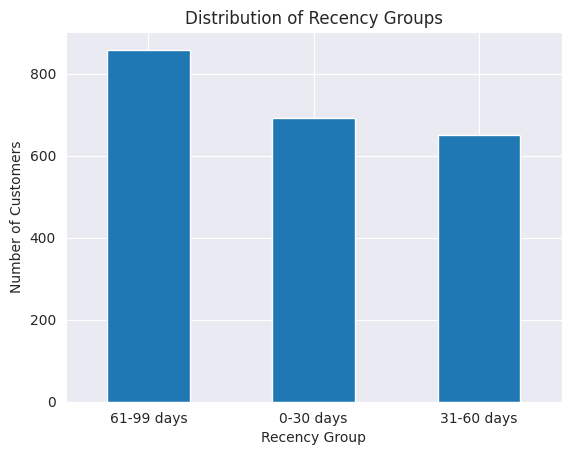

In [ ]:
sns.set_style('darkgrid')
df.Recency_Group.value_counts().plot.bar()
plt.title('Distribution of Recency Groups')
plt.xlabel('Recency Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

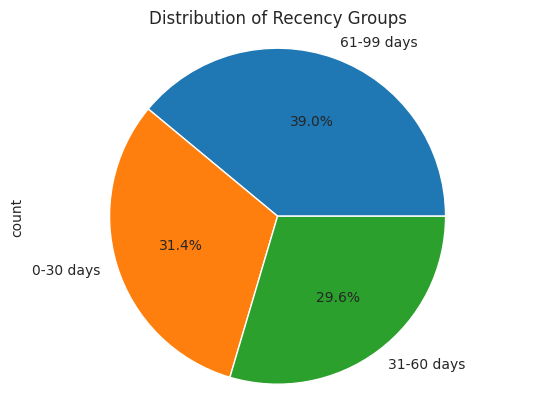

In [ ]:
sns.set_style('darkgrid')
df.Recency_Group.value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Distribution of Recency Groups')
plt.axis('equal')
plt.show()

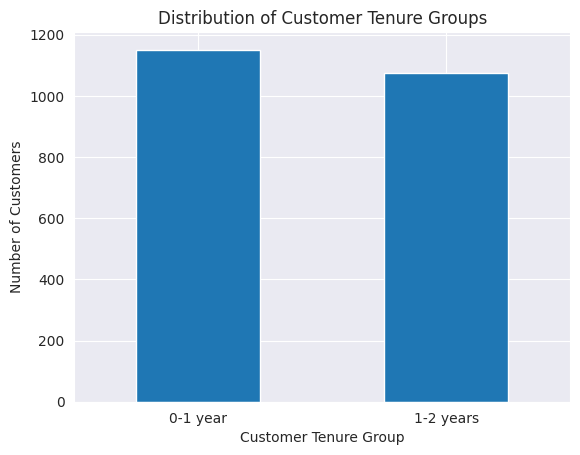

In [ ]:
sns.set_style('darkgrid')
df.CustomerTenure_Group.value_counts().plot.bar()
plt.title('Distribution of Customer Tenure Groups')
plt.xlabel('Customer Tenure Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

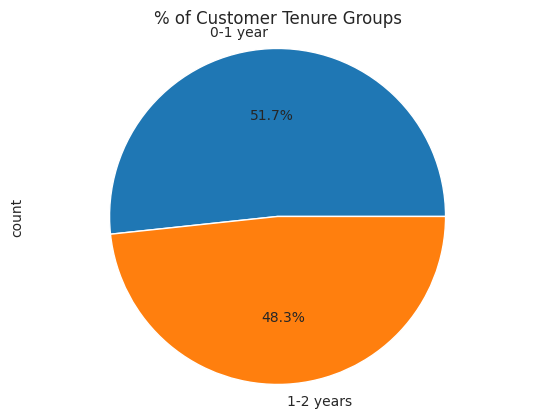

In [ ]:
sns.set_style('darkgrid')
df.CustomerTenure_Group.value_counts().plot.pie(autopct="%1.1f%%")
plt.title('% of Customer Tenure Groups')
plt.axis('equal')
plt.show()

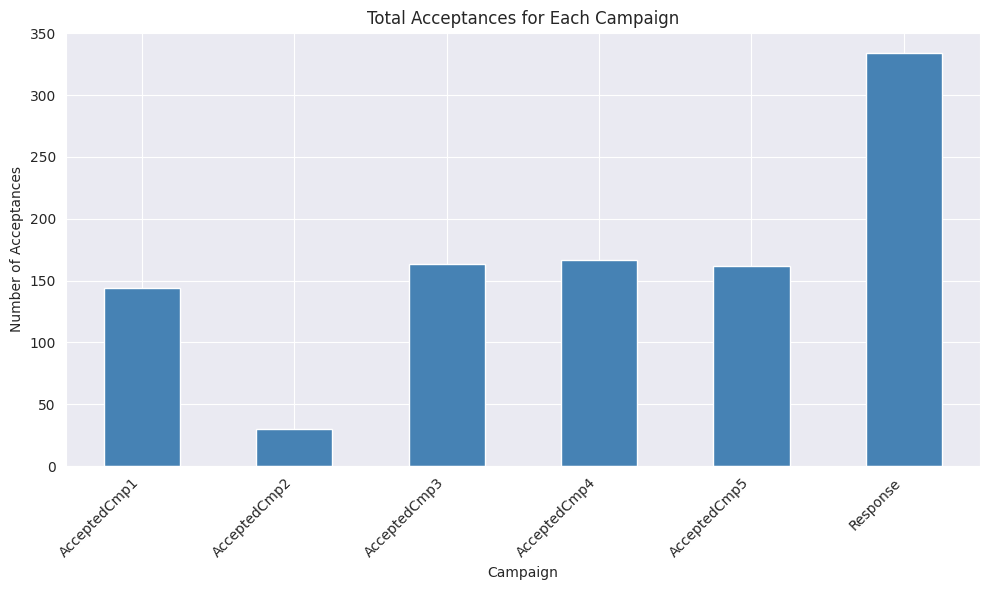

In [ ]:
campaign_columns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
campaign_acceptances = df[campaign_columns].sum()

plt.figure(figsize=(10, 6))
campaign_acceptances.plot(kind='bar', color='steelblue') # Using .plot(kind='bar') directly on the Series
plt.title('Total Acceptances for Each Campaign')
plt.xlabel('Campaign')
plt.ylabel('Number of Acceptances')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

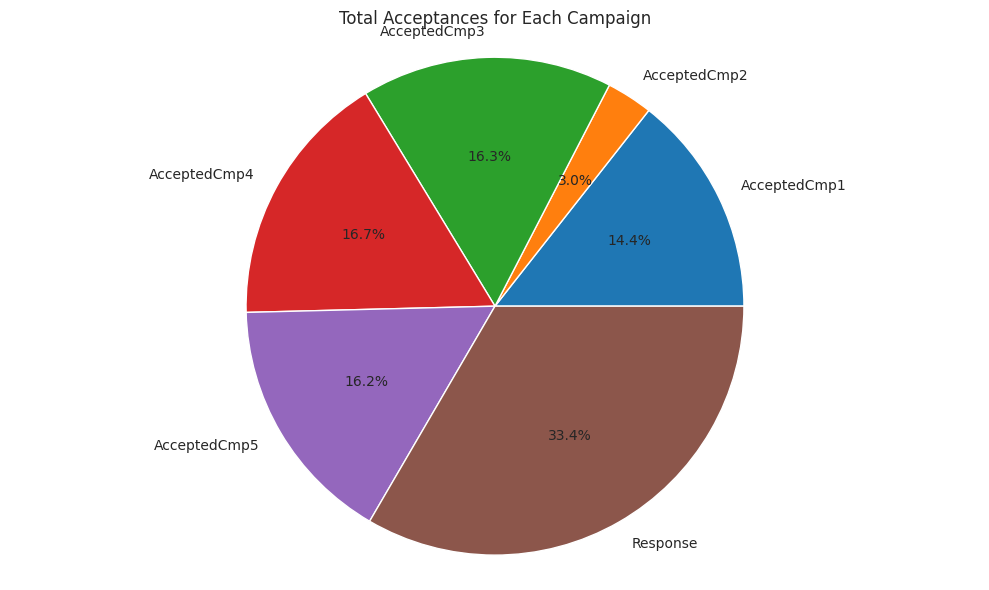

In [ ]:
plt.figure(figsize=(10, 6))
campaign_acceptances.plot.pie(autopct='%1.1f%%')
plt.title('Total Acceptances for Each Campaign')
plt.tight_layout()
plt.axis('equal')
plt.show()

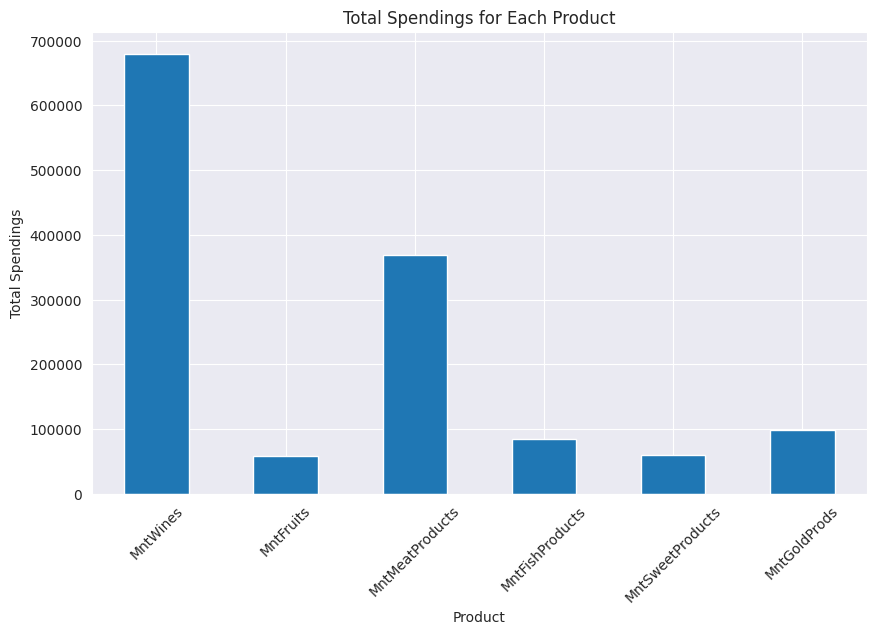

In [ ]:
sns.set_style('darkgrid')
plt.figure(figsize=(10, 6))
products_columns =['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
products_spendings = df[products_columns].sum()
products_spendings.plot.bar()
plt.title('Total Spendings for Each Product')
plt.xlabel('Product')
plt.ylabel('Total Spendings')
plt.xticks(rotation=45)
plt.show()

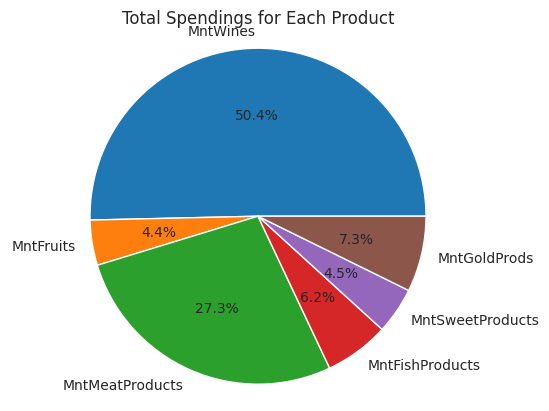

In [ ]:
products_spendings.plot.pie(autopct='%1.1f%%')
plt.title('Total Spendings for Each Product')
plt.axis('equal')
plt.show()

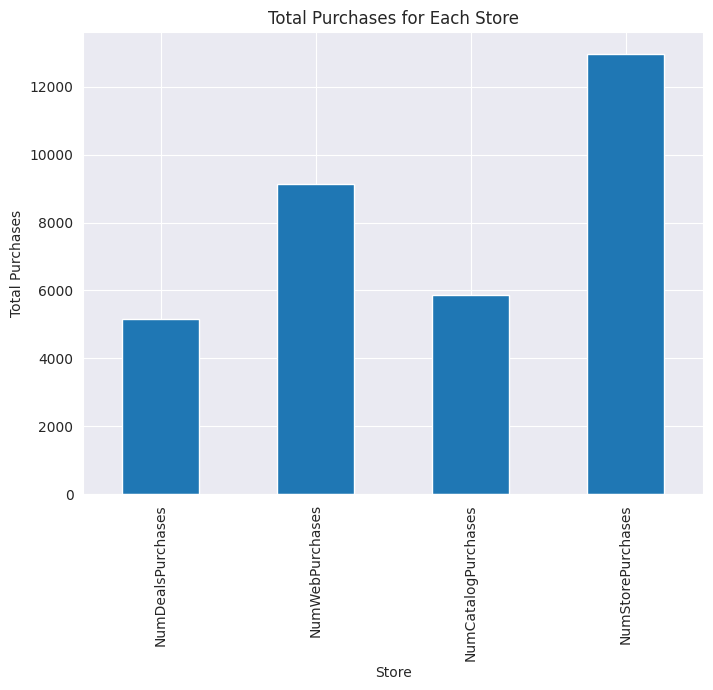

In [ ]:
sns.set_style('darkgrid')
plt.figure(figsize=(8, 6))
purchases_columns =['NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumStorePurchases']
purchases_total = df[purchases_columns].sum()
purchases_total.plot.bar()
plt.title('Total Purchases for Each Store')
plt.xlabel('Store')
plt.ylabel('Total Purchases')
plt.show()

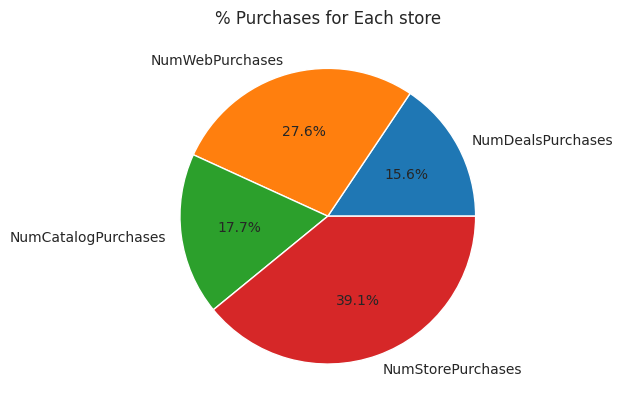

In [ ]:
purchases_total.plot.pie(autopct='%1.1f%%')
plt.title('% Purchases for Each store')
plt.axis='equal'
plt.show()

<Figure size 1000x600 with 0 Axes>

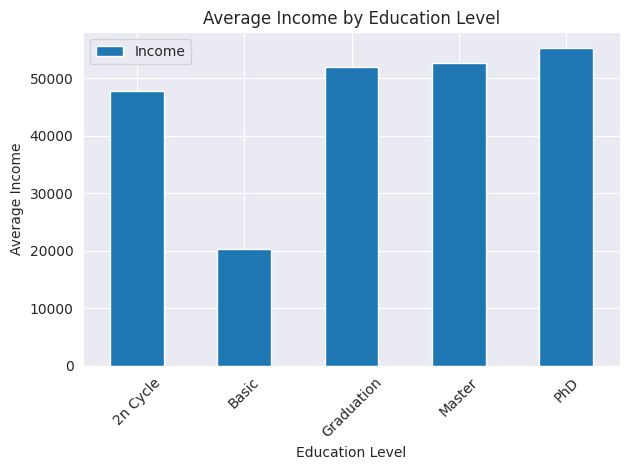

In [ ]:
education_income = df.groupby('Education')['Income'].mean().reset_index()
plt.figure(figsize=(10, 6))
education_income.plot(kind='bar', x='Education', y='Income')
plt.title('Average Income by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Income')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

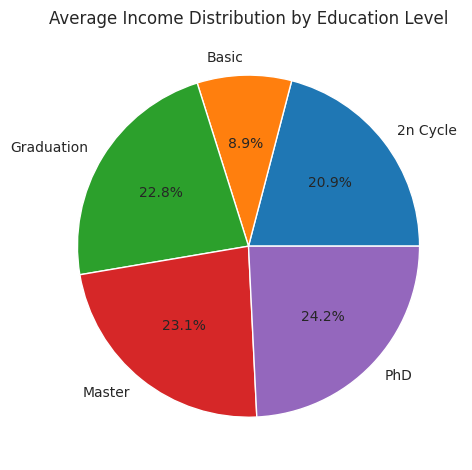

In [ ]:

education_income.plot.pie(y='Income', labels=education_income['Education'], autopct='%1.1f%%', legend=False)
plt.title('Average Income Distribution by Education Level')
plt.ylabel('')
plt.axis='equal'
plt.tight_layout()
plt.show()

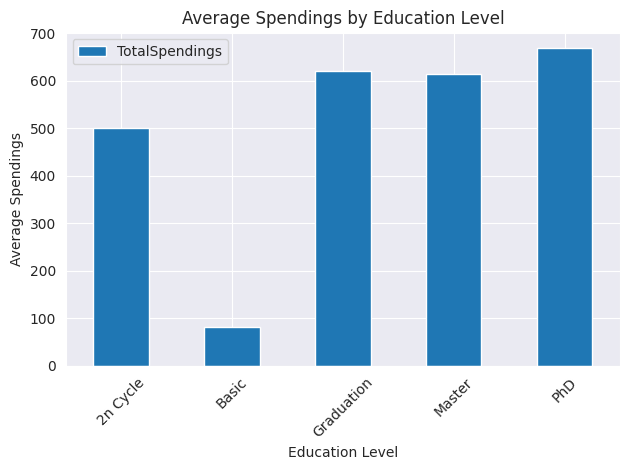

In [ ]:
df.groupby('Education')['TotalSpendings'].mean().reset_index().plot.bar(x='Education',y='TotalSpendings')
plt.title('Average Spendings by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Spendings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Text(0, 0.5, '')

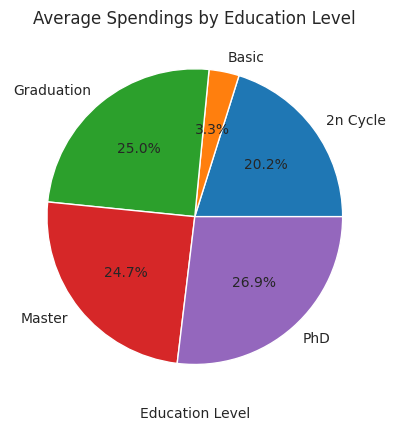

In [ ]:
df.groupby('Education')['TotalSpendings'].mean().reset_index().plot.pie(y='TotalSpendings',labels=education_income['Education'],autopct='%1.1f%%',legend=False)
plt.title('Average Spendings by Education Level')
plt.xlabel('Education Level')
plt.ylabel('')

Text(0, 0.5, 'Average Purchases')

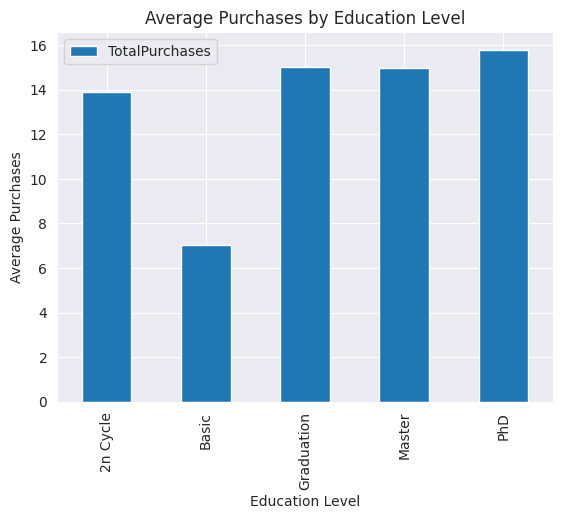

In [ ]:
df.groupby('Education')['TotalPurchases'].mean().reset_index().plot.bar(x='Education',y='TotalPurchases')
plt.title('Average Purchases by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Purchases')

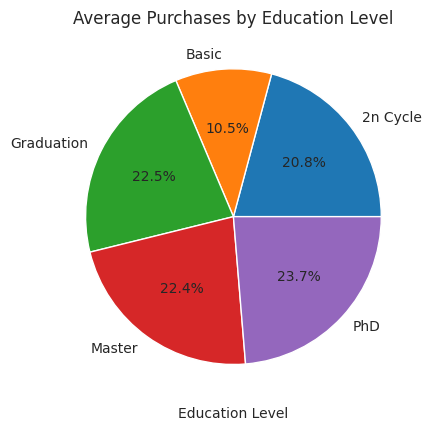

In [ ]:
df.groupby('Education')['TotalPurchases'].mean().reset_index().plot.pie(y='TotalPurchases',labels=education_income['Education'],autopct='%1.1f%%',legend=False)
plt.title('Average Purchases by Education Level')
plt.xlabel('Education Level')
plt.ylabel('')
plt.axis='equal'
plt.show()

<Figure size 1000x600 with 0 Axes>

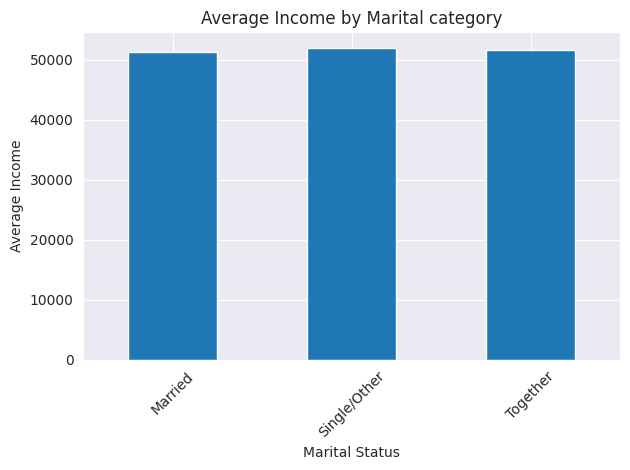

In [ ]:
Marital_income = df.groupby('Marital_Status')['Income'].mean().reset_index()
plt.figure(figsize=(10, 6))
education_income.plot.bar( x='Marital_Status', y='Income',legend = False)
plt.title('Average Income by Marital category')
plt.xlabel('Marital Status')
plt.ylabel('Average Income')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

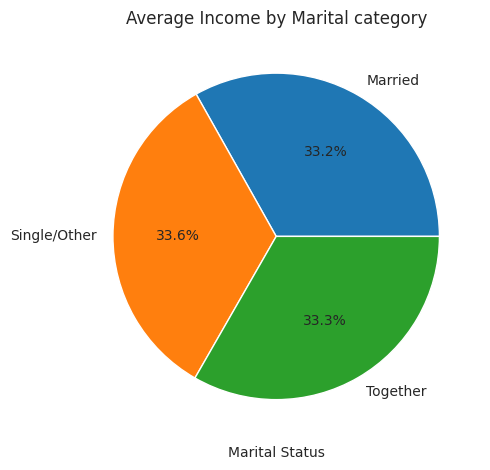

In [ ]:
Marital_income.plot.pie( y='Income',labels =education_income['Marital_Status'],autopct='%1.1f%%',legend = False)
plt.title('Average Income by Marital category')
plt.xlabel('Marital Status')
plt.ylabel('')
plt.axis='equal'
plt.tight_layout()
plt.show()

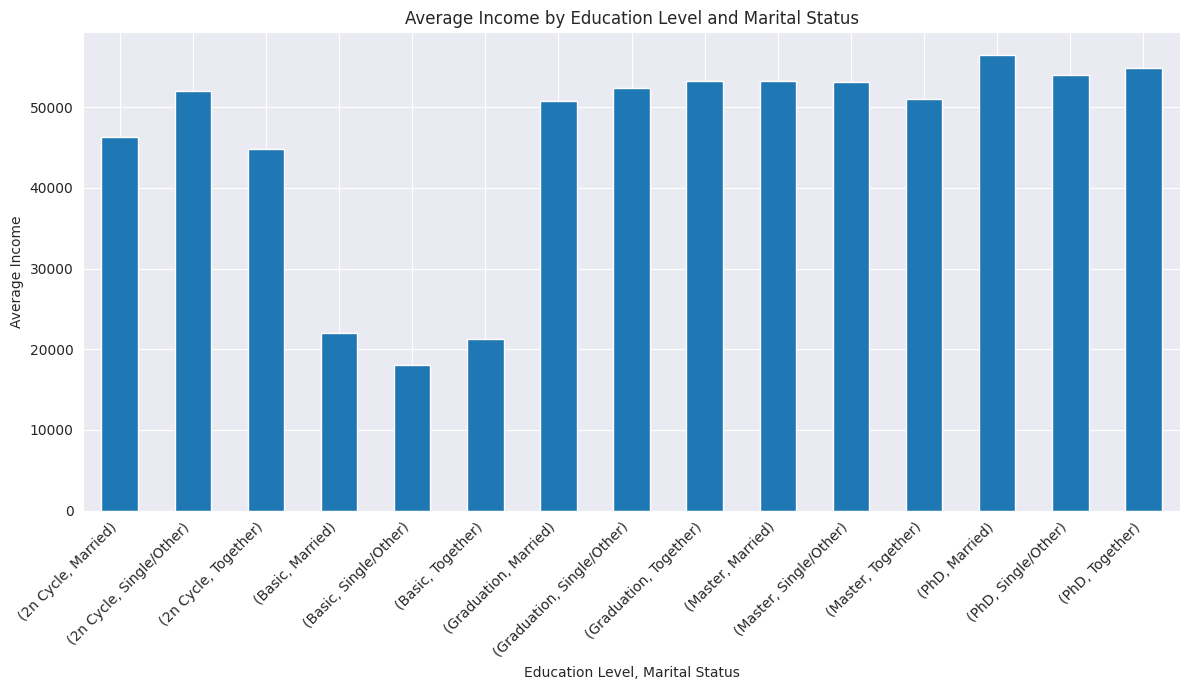

In [ ]:
Education_Marital_income = df.groupby(['Education','Marital_Status'])['Income'].mean().reset_index()
plt.figure(figsize=(12, 7))
Education_Marital_income.set_index(['Education', 'Marital_Status'])['Income'].plot(kind='bar', legend=False)
plt.title('Average Income by Education Level and Marital Status')
plt.xlabel('Education Level, Marital Status')
plt.ylabel('Average Income')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

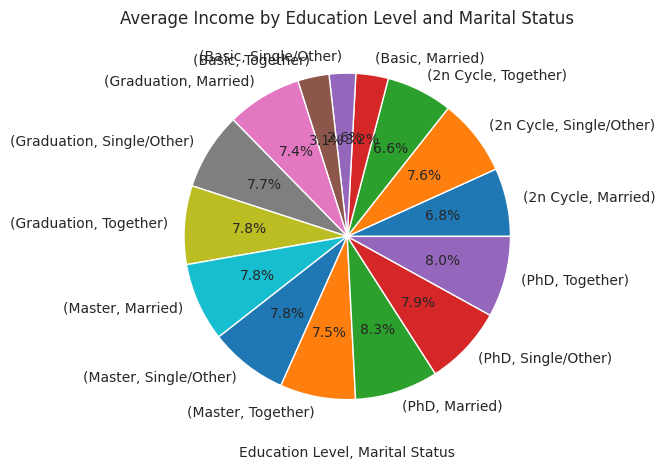

In [ ]:
Education_Marital_income.set_index(['Education', 'Marital_Status'])['Income'].plot(kind='pie', autopct='%1.1f%%', legend=False)
plt.title('Average Income by Education Level and Marital Status')
plt.xlabel('Education Level, Marital Status')
plt.ylabel('')
plt.axis='equa;'
plt.tight_layout()
plt.show()

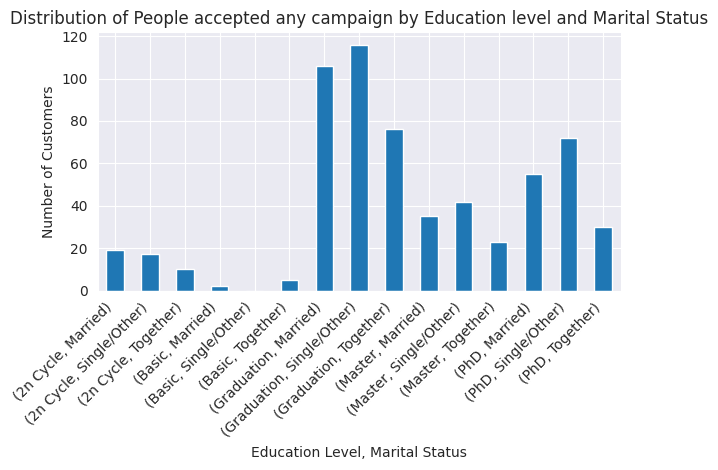

In [ ]:
df.groupby(['Education','Marital_Status'])['AcceptedAtAll'].sum().plot.bar()
plt.title('Distribution of People accepted any campaign by Education level and Marital Status')
plt.xlabel('Education Level, Marital Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

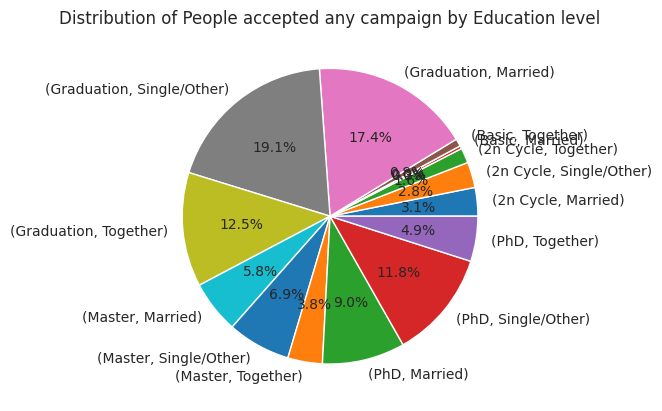

In [ ]:
df.groupby(['Education','Marital_Status']).AcceptedAtAll.sum().plot.pie(autopct='%1.1f%%')
plt.title('Distribution of People accepted any campaign by Education level')
plt.axis='equal'
plt.ylabel('')
plt.show()

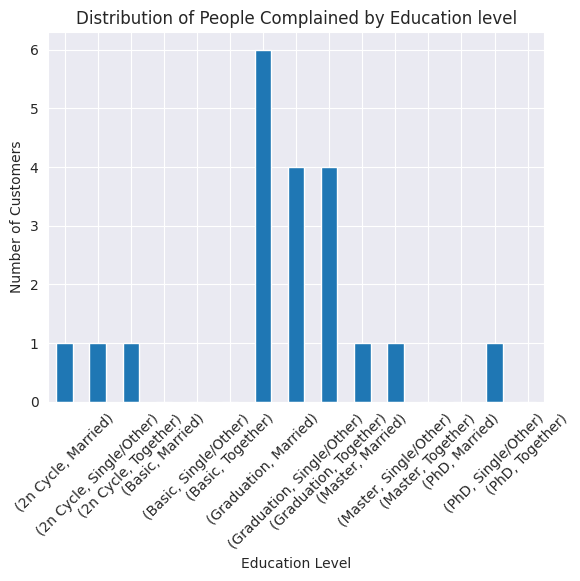

In [ ]:
df.groupby(['Education','Marital_Status']).Complain.sum().plot.bar()
plt.title('Distribution of People Complained by Education level')
plt.xlabel('Education Level')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

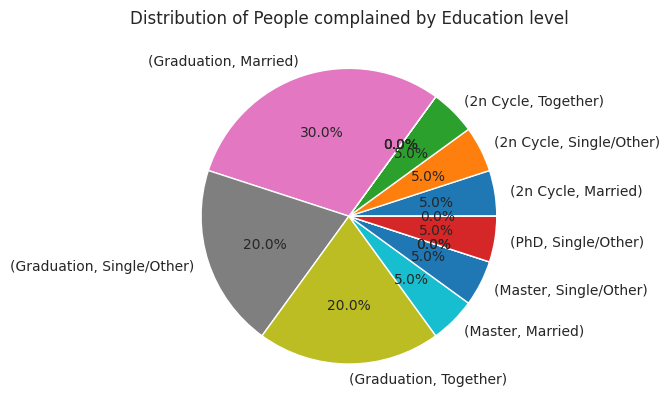

In [ ]:
df.groupby(['Education','Marital_Status']).Complain.sum().plot.pie(autopct='%1.1f%%')
plt.title('Distribution of People complained by Education level')
plt.ylabel('')
plt.axis='equal'
plt.show()

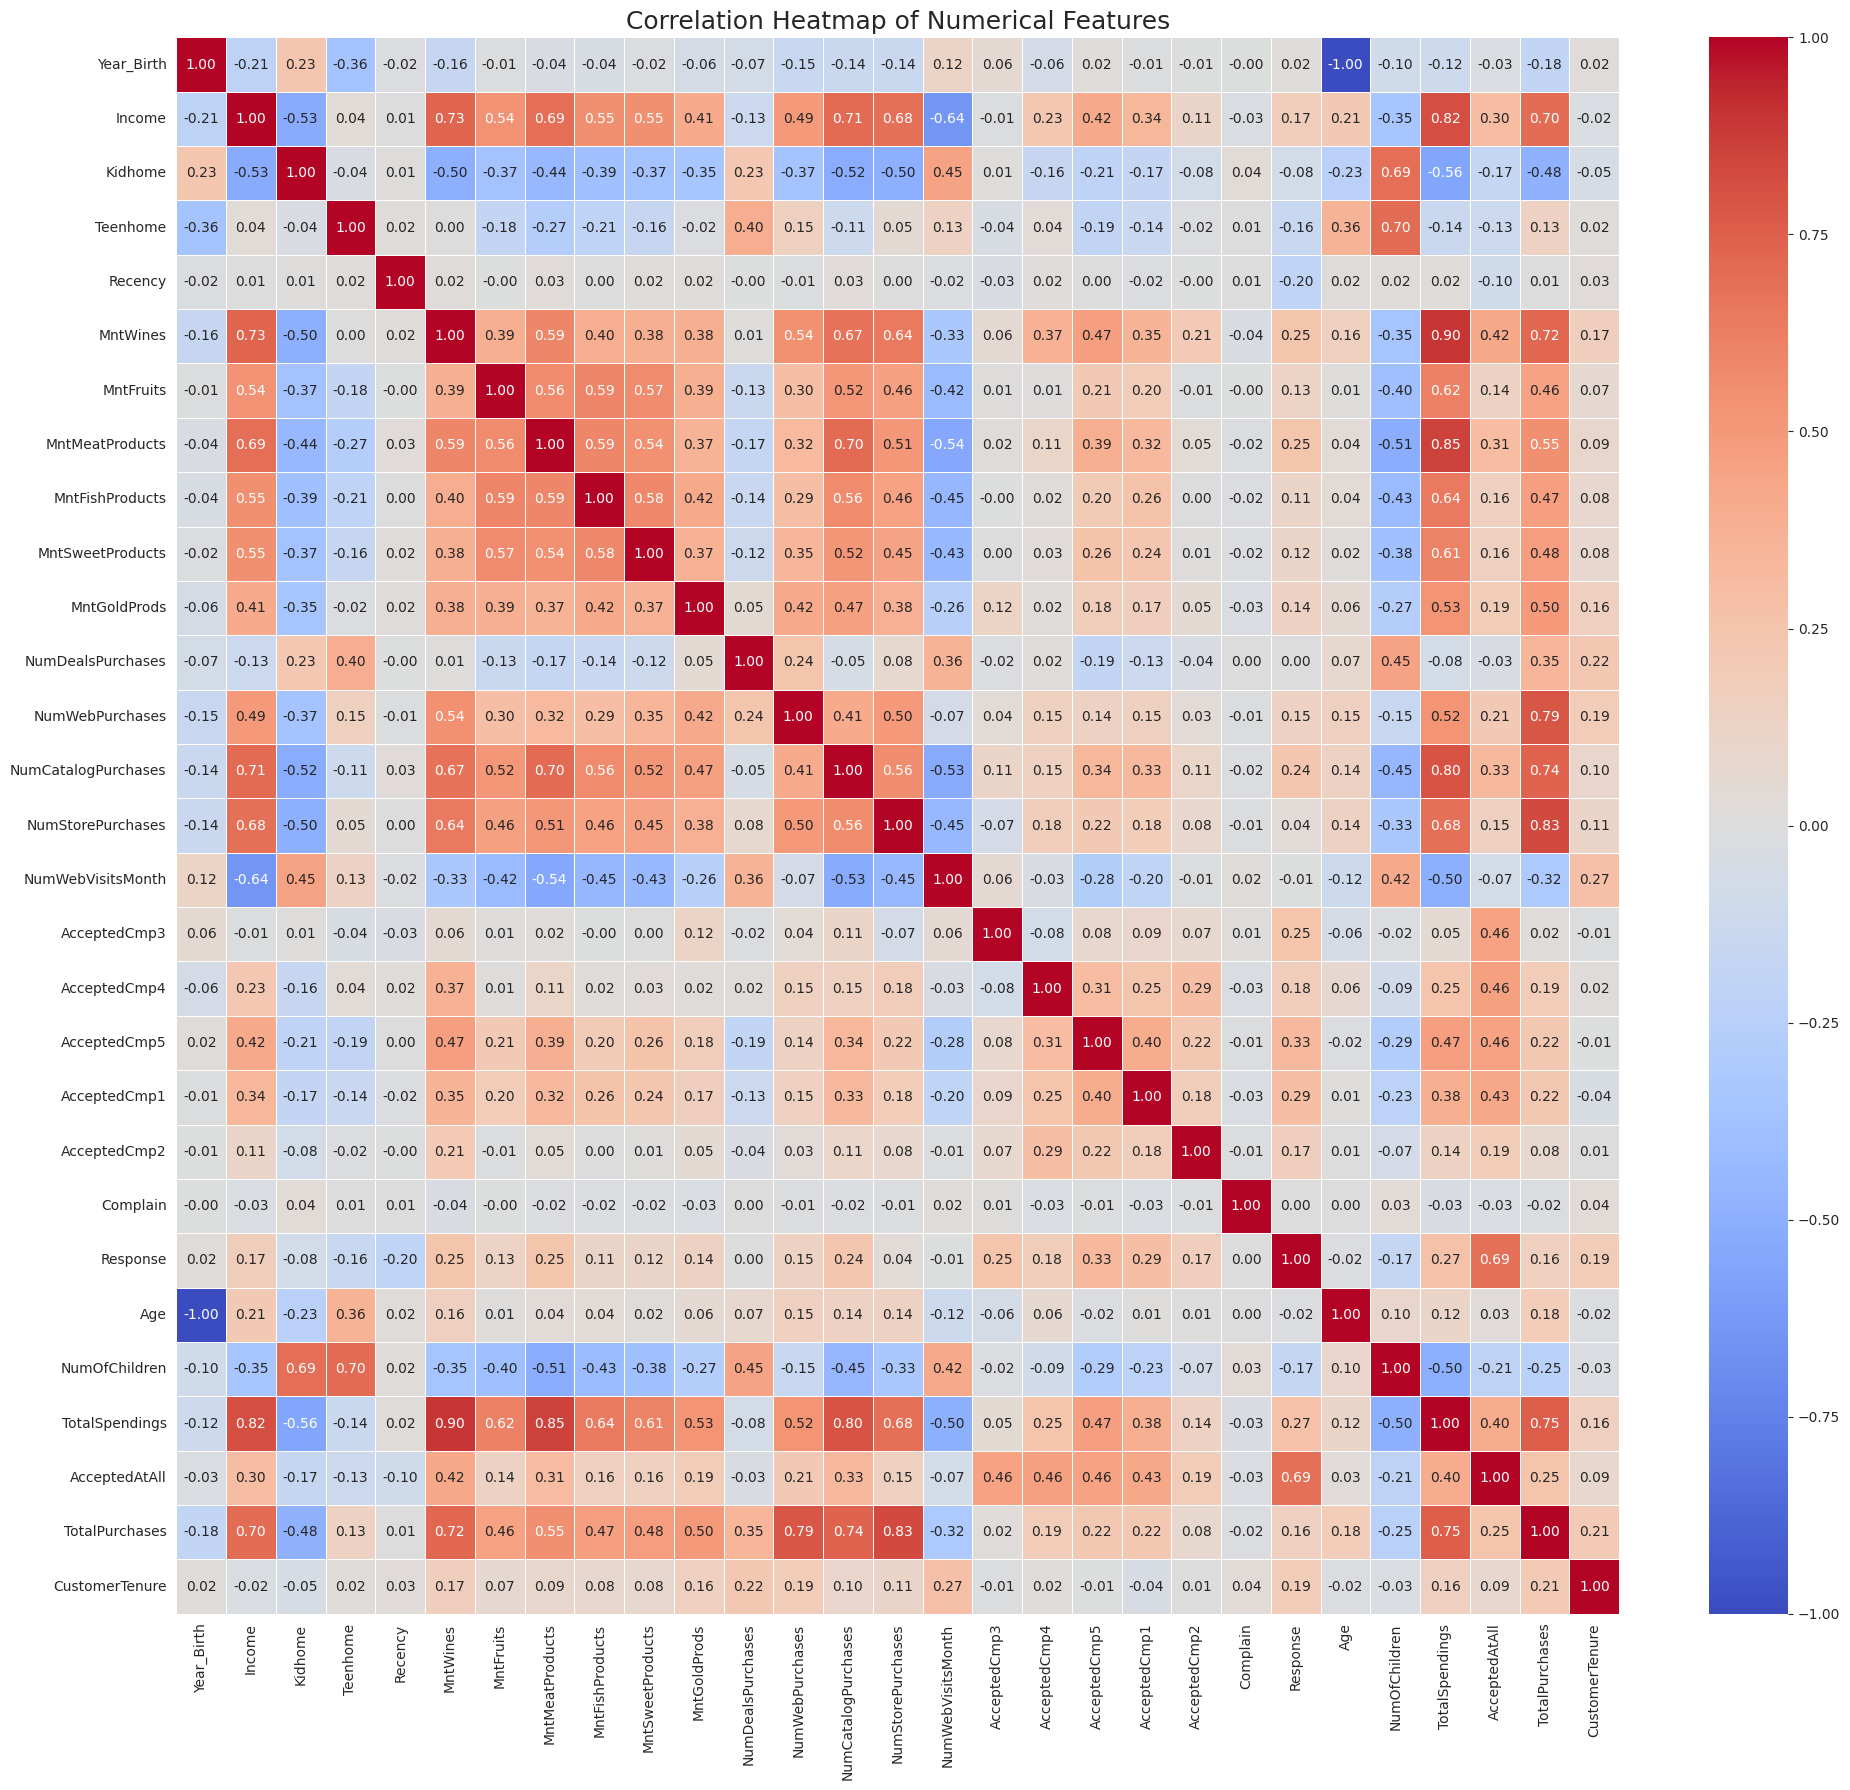

In [ ]:
numerical_df = df.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=18)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()